--- Previsões com MMQ Polinomial para o Mês 72 ---
Grau 4: -519.90 mm
Grau 5: -156.92 mm
Grau 6: -1185.86 mm
Grau 7: -5433.70 mm
Grau 8: -850.29 mm
Grau 9: -12446.44 mm
Grau 10: -31924.69 mm


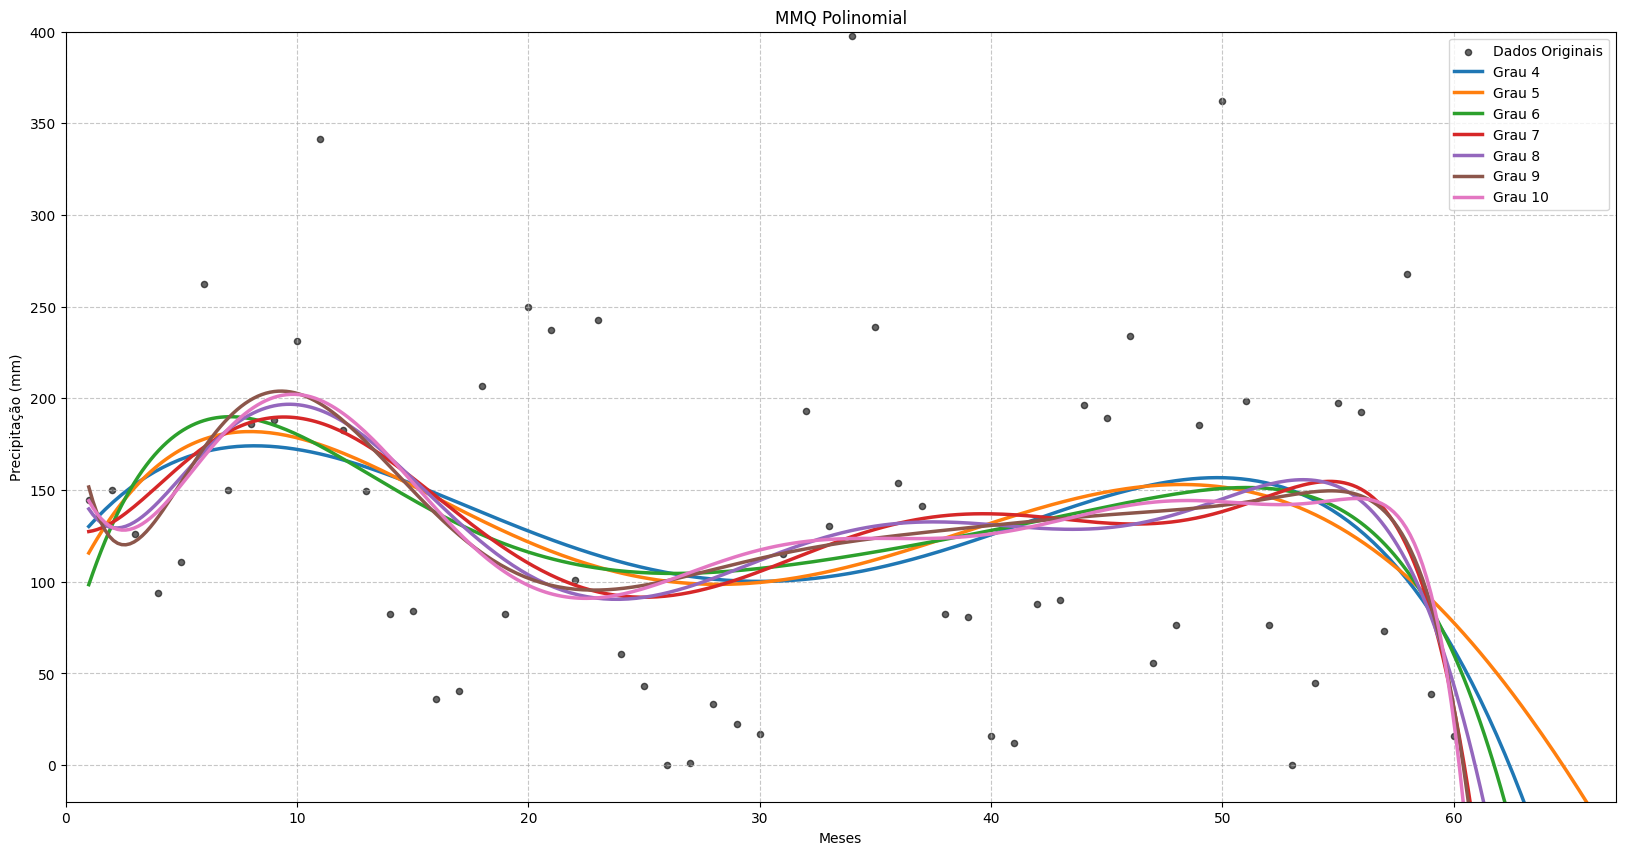

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])


# --- Estrutura Principal do Gráfico Comparativo ---

# 1. Criar a figura e os eixos UMA VEZ
plt.figure(figsize=(20, 10))
# 2. Plotar os dados originais UMA VEZ
plt.scatter(x_dados, y_dados, label='Dados Originais', color='black', alpha=0.6, s=20)

print("--- Previsões com MMQ Polinomial para o Mês 72 ---")

# Vamos testar alguns graus baixos e um grau um pouco mais alto para ver o overfitting
graus_a_testar = np.arange(4,11)

# 3. Loop para calcular e plotar cada modelo polinomial
for grau in graus_a_testar:
    
    # Ajustar o polinômio de grau baixo usando MMQ
    coeficientes = np.polyfit(x_dados, y_dados, grau)
    polinomio_mmq = np.poly1d(coeficientes)
    
    # Gerar a curva de tendência
    x_curva = np.linspace(1, 72, 400)
    y_curva = polinomio_mmq(x_curva)
    
    # Plotar a curva do modelo atual no mesmo gráfico
    plt.plot(x_curva, y_curva, label=f'Grau {grau}', linewidth=2.5)
    
    # Calcular e imprimir a previsão
    mes_futuro = 72
    precipitacao_prevista = polinomio_mmq(mes_futuro)
    print(f"Grau {grau}: {precipitacao_prevista:.2f} mm")


# 4. Configurar os detalhes do gráfico DEPOIS do loop
plt.title('MMQ Polinomial')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.ylim(-20, 400)
plt.xlim(0,67)
plt.show()

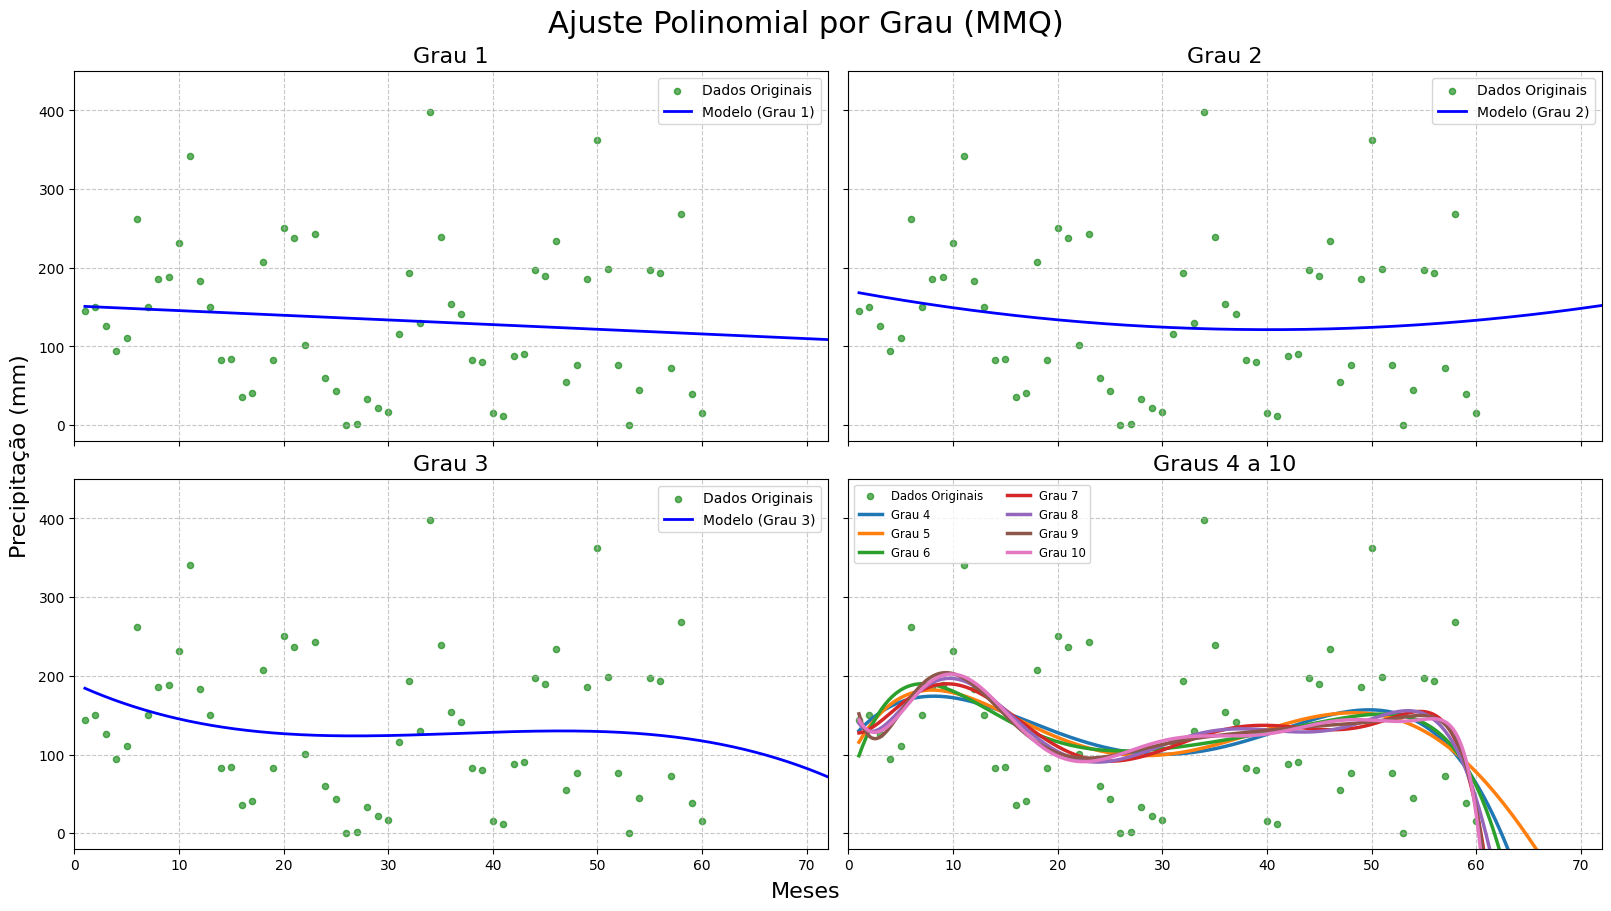

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados (sem alterações) ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Estrutura Principal do Gráfico com Subplots ---

# 1. Criar a figura usando constrained_layout=True e um tamanho mais compacto
fig, axs = plt.subplots(2, 2, 
                        figsize=(16, 9), 
                        sharex=True, 
                        sharey=True, 
                        constrained_layout=True) # <-- MUDANÇA PRINCIPAL AQUI

fig.suptitle('Ajuste Polinomial por Grau (MMQ)', fontsize=22)

# 2. Loop para os 3 primeiros gráficos (graus 1, 2 e 3)
for grau in range(1, 4):
    row = (grau - 1) // 2
    col = (grau - 1) % 2
    ax = axs[row, col]

    # Ajusta o polinômio e cria a função
    coeficientes = np.polyfit(x_dados, y_dados, grau)
    polinomio = np.poly1d(coeficientes)

    # Gera a curva de tendência
    x_curva = np.linspace(min(x_dados), 72, 400)
    y_curva = polinomio(x_curva)

    # Plota os dados e a curva no subplot correto
    ax.scatter(x_dados, y_dados, color='green', alpha=0.6, s=20, label='Dados Originais')
    ax.plot(x_curva, y_curva, color='blue', linewidth=2, label=f'Modelo (Grau {grau})')

    # Adiciona título, grade e legenda individuais
    ax.set_title(f'Grau {grau}', fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

# 3. Lógica para o quarto gráfico (graus 4 a 10)
ax_multi = axs[1, 1] 

# Plota os dados originais apenas uma vez
ax_multi.scatter(x_dados, y_dados, color='green', alpha=0.6, s=20, label='Dados Originais')

# Loop para plotar múltiplas curvas de modelo
for grau in range(4, 11):
    coeficientes = np.polyfit(x_dados, y_dados, grau)
    polinomio = np.poly1d(coeficientes)
    x_curva = np.linspace(min(x_dados), 72, 400)
    y_curva = polinomio(x_curva)
    ax_multi.plot(x_curva, y_curva, linewidth=2.5, label=f'Grau {grau}')

# Adiciona título, grade e legenda ao quarto gráfico
ax_multi.set_title('Graus 4 a 10', fontsize=16)
ax_multi.grid(True, linestyle='--', alpha=0.7)
ax_multi.legend(fontsize='small', ncol=2) # ncol=2 para organizar a legenda


# 4. Adicionar rótulos comuns para os eixos X e Y
fig.supxlabel('Meses', fontsize=16)
fig.supylabel('Precipitação (mm)', fontsize=16)

# 5. Definir os limites dos eixos para todos os gráficos
plt.xlim(0, 72)
plt.ylim(-20, 450)

# 6. REMOVER a linha plt.tight_layout(...), pois o constrained_layout já faz o trabalho
# plt.tight_layout(rect=[0.05, 0.05, 1, 0.94]) # <-- REMOVIDO

plt.show()